In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,r2_score

## Part A: Conceptual Questions

1. What is a Decision Tree and how does it make decisions?
   - Decision Tree is a non-parametric supervised machine learning algorithm,used for both classification and reggresion.
   - It makes decisions by splitting the data into tree structure based on conditions
   - splitting can be done on the basis of information gain on features using gini impurity

2. What does a split criterion mean in a Decision Tree?
   - At first root node has be selected based on the max information gain among all the features
   - Split criterion divides data into two parts at each split , by asking questions on the features on its ranges


3. Difference between Gini Impurity and Entropy.
   - Both the Gini impurity and Entropy are Error Calculation metrics used on a categorical data
   - Gini impurity is the measure of impurity , it is the probability of misclassification of randomly choosen sample
   - Entropy is the measure of disorder in the data
   - Entropy is computationally complex compared to gini impurity
   - After splitting the data ,if error is zero than those nodes are called pure nodes
   - For pure nodes both the entropy and gini impurity are zero
   - Incase of impure node both the values are different 

4. Why do Decision Trees tend to overfit?
   - Decision tree splits the data recursively upto the each leaf nodes becomes pure, as it tends to overfitting by memorizing the data.

5. What role does the max_depth parameter play?
   - It is a Pre_Prunning parameter used to limit the tree depth,as it helps in avoiding the overfitting

## Part B: Data Exploration

1. Load the dataset and display:
   - Shape of the dataset
   - Column names
   - First 5 rows

In [4]:
df = pd.read_csv(r"C:\Users\HP\Downloads\archive (3)\heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.shape

(1025, 14)

In [6]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

2. Identify:
   - Target column
   - Feature columns

In [7]:
df['target'].head() #Target

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [8]:
df.drop('target',axis=1).head() #Features

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


3. Check and report:
   - Missing values
   - Data types

In [7]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

- There are no missing values in the dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## Part C: Data Preprocessing

- Separate features and target

In [9]:
X = df.drop('target',axis=1)
y = df['target']
X.shape,y.shape

((1025, 13), (1025,))

- Split the data into trainning and testing

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((820, 13), (205, 13), (820,), (205,))

## Part D: Model Building

In [11]:
dtc = DecisionTreeClassifier(criterion='gini',random_state=42)
dtc

DecisionTreeClassifier(random_state=42)

In [12]:
dtc.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [13]:
y_pred = dtc.predict(X_test)
y_pred

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0], dtype=int64)

##  Part E: Model Evaluation

- accuracy score

In [14]:
accuracy_score(y_pred,y_test)

0.9853658536585366

- confusion matrix

In [16]:
confusion_matrix(y_pred,y_test)

array([[102,   3],
       [  0, 100]], dtype=int64)

- classification report

##  Part F: Understanding Tree Depth (Manual Experiment)

- Train three models by changing only max_depth:

In [19]:
model1 = DecisionTreeClassifier(max_depth=2)
model1

DecisionTreeClassifier(max_depth=2)

In [20]:
model1.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=2)

In [34]:
model1.score(X_train,y_train)

0.7695121951219512

In [23]:
y_pred1 = model1.predict(X_test)
y_pred1

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 0], dtype=int64)

In [33]:
accuracy_score(y_pred1,y_test)

0.6780487804878049

In [28]:
model2 = DecisionTreeClassifier(max_depth=5)
model2

DecisionTreeClassifier(max_depth=5)

In [29]:
model2.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [30]:
model2.score(X_train,y_train)

0.9292682926829269

In [31]:
y_pred2 = model2.predict(X_test)
y_pred2

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0], dtype=int64)

In [32]:
accuracy_score(y_pred2,y_test)

0.8439024390243902

In [35]:
model3 = DecisionTreeClassifier()
model3

DecisionTreeClassifier()

In [37]:
model3.fit(X_train,y_train)

DecisionTreeClassifier()

In [38]:
model3.score(X_train,y_train)

1.0

In [39]:
y_pred3 = model3.predict(X_test)
y_pred3

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0], dtype=int64)

In [40]:
accuracy_score(y_pred3,y_test)

0.9853658536585366

1. What happens when the tree is very shallow?
 - If the tree is shallow both the training and testing accuracy of the model reduced.
 - It helps in avoiding overfitting

2. What happens when the tree is very deep?
- If the tree is very deep, model create a tree with all pure leaf nodes
- It results in memorizing the data while at the time of training
- Incase of testing, model cannot predict well as it memorizes
- Also computationally Complex to build a tree very deep

3. Which model performs best and why?
- model with default max_depth performs well compared to other two,if max_depth is None tree builts upto every leaf node is pure that's why it performs well

## Part G: Tree Visualization

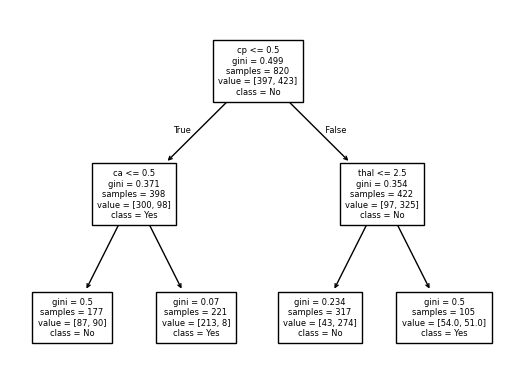

In [50]:
plot_tree(model1,feature_names=X_train.columns,fontsize=6,class_names=['Yes','No']);

In [51]:
model1.tree_.max_depth

2

## Part H: Reflection Questions

1. Why are Decision Trees suitable for medical datasets?
- Decision trees are in the tree structure easy to read and understand makes easy in medical field to take decisions
- We can also know which feature more contributing for the disease by information gain among all the features
- Feature scaling may effects the values in the medical reports as there is no need of feature scaling in the decision tree
- Decision tree deals with both numerical and categorical data,optimal use of every features in the medical reports

2. What makes Decision Trees easy to interpret?
- Decision tree is easy to interpret because the decisions are in the form of the tree structure
- There is a condition at each node to split the data
- leaf nodes represent the final predictions

## Finally Check with these below parameter

- Compare criterion='gini' vs criterion='entropy'

In [31]:
dtc_gini = DecisionTreeClassifier(criterion='gini',random_state=42)
dtc_gini

DecisionTreeClassifier(random_state=42)

In [32]:
dtc_gini.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [33]:
dtc_gini.score(X_train,y_train)

1.0

In [34]:
y_gini = dtc_gini.predict(X_test)
y_gini

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0], dtype=int64)

In [15]:
accuracy_score(y_gini,y_test)

0.9853658536585366

In [17]:
dtc_entropy = DecisionTreeClassifier(criterion='entropy',random_state=42)
dtc_entropy

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [18]:
dtc_entropy.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [20]:
y_entropy = dtc_entropy.predict(X_test)
y_entropy

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0], dtype=int64)

In [22]:
dtc_entropy.score(X_train,y_train)

1.0

In [21]:
accuracy_score(y_entropy,y_test)

0.9853658536585366

In [58]:
dtc_gini = DecisionTreeClassifier(criterion='gini',random_state=42,min_samples_leaf=5)
dtc_gini

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

In [59]:
dtc_gini.fit(X_train,y_train)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

In [60]:
dtc_gini.score(X_train,y_train)

0.9536585365853658

In [61]:
y_pred = dtc_gini.predict(X_test)

In [62]:
accuracy_score(y_pred,y_test)

0.8975609756097561

- Incase of `max_samples_leaf` default the model tends to overfit,it memorizes the data by splitting each the nodes into pure leafs.
- To avoid overfitting we have to assign a value to `max_samples_leaf = 5`